#### run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [1]:
# !pip install xgboost
# !pip install imbalanced-learn
# !pip install catboost
# !pip install optuna
# !pip install torch
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
import random
import torch
import optuna
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
random.seed(35)
np.random.seed(35)

client = bigquery.Client()

def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [2]:
# Get features
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
    , e.* EXCEPT (individual_id)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features_v2` AS f
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_embeddings` AS e
        ON f.asdb_member_key = e.individual_id
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
    
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape
#2,542,308 members who qualify with 564 features we are exploring

(2542308, 561)

In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_og = client.query(sql).to_dataframe() 
outcome_og.shape

(2542308, 2)

### Data Preprocessing

#### Fill in zeros

In [4]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df_og.columns if re.match(emb_pattern ,col)]
df_og[emb_col] = df_og[emb_col].fillna(0)
for c in df_og.columns: 
    dt = df_og[c].dtype
    if is_integer(dt) or is_float(dt):
        df_og[c]=df_og[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df_og[c]= df_og[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

In [5]:
# df = df_og
# outcome = outcome_og

# print(df.shape)
# print(outcome.shape)

#### One Hot Encode Categorical

In [6]:
#  0 := categorical, 1 := continuous, 2 := binary
nem_to_type = {
    'narc':2, 
    # 'otc_fills_yr2': 1,
    # 'otc_fills_yr1':1,  
    'COP':2, 
    'sleep_apnea':2, 
    'spinal_inj':2,
    'back':2,
    'substance':2,
    'ALC':2,
    'bipolar':2,
    'psychoses':2,
    'EDO':2, 
    'SCA':2, 
    'DIA':2, 
    'DEP':2, 
    'abdominal_pain':2, 
    'OST':2, 
    'AID':2, 
    'IDA':2, 
    'ANX':2, 
    'DEM':2, 
    'CYS':2, 
    'autoimmune':2, 
    'MOH':2, 
    'HEM':2, 
    'esrd':2, 
    'HepC':2, 
    'HYP':2, 
    'HYC':2, 
    'immune':2, 
    'intel_dsblty':2, 
    'meta_cancer':2, 
    'liver_dis':2, 
    'MSS':2, 
    'OBE':2, 
    'oud':2, 
    'liver_other':2, 
    'paralysis':2, 
    'PAR':2, 
    'PUD':0, 
    'hmd':2, 
    'PVD':2, 
    'CRO':2, 
    'AST':2, 
    'EPL':2, 
    'low_med_sev_ed_flag_yr2':2, 
    'med_high_sev_ed_flag_yr2':2, 
    'high_sev_ed_flag_yr2':2, 
    'acute_ip_flag_yr1':2, 
    'CHO':2,
    'burns':2, 
    'acute_ip_flag_yr2':2, 
    'cad':2, 
    'Cancer':2, 
    'ed_flag_yr2':2, 
    'high_sev_ed_flag_yr1':2, 
    'med_sev_ed_flag_yr2':2, 
    'AUT':2, 
    'med_high_sev_ed_flag_yr1':2, 
    'low_med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr1':2, 
    'CBD':2, 
    'CHF':2, 
    'CRF':2, 
    'VNA':2, 
    'CHD':2, 
    'ed_flag_yr1':2, 
    'med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr2':2, 
    'urbsubr':0, 
    'gender':0, # TODO: IF = M, 1 ELIF = F 0 ELSE NULL 
    'cms_prost_cancer_scrn':0, 
    'cms_hpv_scrn':0, 
    'cms_cvd_scrn':0, 
    'cms_lung_cancer_scrn':0, 
    'cms_pelvic':0,
    'coa_population_group':0, 
    'cms_pap':0, 
    'cms_t2d_scrn':0, 
    'cms_bone_scrn':0, 
    'cms_alc_scrn':0,
    'cms_ibt_cvd':0, 
    'cms_col_scrn':0,
    'index_dt':0, 
    'cms_ibt_obese':0, 
    'cms_flu_vax':0, 
    'cms_pneum_vax':0, 
    'cms_dep_scrn':0,
    'tenure_yr2':1, # either 
    'tenure_yr1':1, # either
    'cms_hepb_vax':0,
    'low_sev_ed_visits_yr2':0, # 7/2/24 removed
    'coa_population_category':0, 
    'cms_mam_scrn':0, # 7/2/24 removed
    'low_sev_ed_visits_yr1':1,
    'sum_acute_ip_admits_yr2':1,
    'sum_acute_ip_admits_yr1':1,
    'cms_tobacco':0,# 7/2/24 removed
    'low_med_sev_ed_visits_yr2':1, 
    'cms_t2d_train':0, # 7/2/24 removed
    'sum_preventable_yr2':1, 
    'cms_hepb_scrn':0, ###
    'sum_preventable_yr1':1, 
    'major_chronic_cnt':1, 
    'low_med_sev_ed_visits_yr1':1,
    'sum_ob':1, 
    'sum_unnecessary_yr2':1, 
    'sum_chol_lab':1, 
    'cms_nutrition':0,  # 7/2/24 removed
    'coe_anesth_clm_yr2':1, 
    'sum_a1c_lab':1, 
    'sum_unnecessary_yr1':1, 
    'sum_avoidable_yr2':1, 
    'gpi2_cnt_yr1':1, 
    'high_sev_ed_visits_yr2':1,
    'gpi2_cnt_yr2':1, 
    'ms_brand_fills_yr2':1, 
    'coe_anesth_clm_yr1':1, 
    'med_sev_ed_visits_yr2':1, 
    'cms_sti_scrn':0, 
    'med_high_sev_ed_visits_yr2':1, 
    'high_sev_ed_visits_yr1':1, 
    'ms_brand_fills_yr1':1, 
    'sum_avoidable_yr1':1, 
    'inhaled_steroid_scripts_yr2':1, 
    'med_high_sev_ed_visits_yr1':1, 
    'med_sev_ed_visits_yr1':1, 
    'inhaled_steroid_scripts_yr1':1, 
    'obs_clm_yr2':1,
    'gpi4_cnt_yr2':1,
    'gpi4_cnt_yr1':1,
    'obs_clm_yr1':1, 
    'sum_dme':1, 
    'antianginal_agent_scripts_yr2':1, 
    'mail_order_fills_yr2':1, 
    'branded_generic_fills_yr2':1, 
    'gpi_cnt_yr1':1,
    'gpi_cnt_yr2':1,
    'adi_score':1, 
    'sdi_score':1, 
    'antianginal_agent_scripts_yr1':1, 
    'ethnicity_code':0, 
    'sum_ed_visits_yr2':1,
    'mail_order_fills_yr1':1,
    'uc_clm_yr2':1, 
    'calcium_channel_blk_scripts_yr2':1,
    'antianxiety_scripts_yr2':1, 
    'beta_blocker_scripts_yr2':1, 
    'sum_ed_visits_yr1':1, 
    'branded_generic_fills_yr1':1,
    'coe_maternity_clm_yr2':1,
    'sum_chemo':1, 
    'agenbr':1, 
    'uc_clm_yr1':1,
    'calcium_channel_blk_scripts_yr1':1,
    'coe_maternity_clm_yr1':1,
    'diuretic_scripts_yr2':1,
    'primarylanguage_desc':0, # TODO: Check counts, limit to other if <2000 ppl
    'beta_blocker_scripts_yr1':1, 
    'antianxiety_scripts_yr1':1,
    'antihypertensive_scripts_yr2':1,
    'ndc_cnt_yr1':1, 
    'ndc_cnt_yr2':1, 
    'lipid_lowering_scripts_yr2':1,
    'diuretic_scripts_yr1':1, 
    'coe_surg_clm_yr2':1, 
    'sum_acute_calc_los_yr1':1, 
    'sum_acute_calc_los_yr2':1,
    'sum_pcp':1, 
    'lipid_lowering_scripts_yr1':1, 
    'antihypertensive_scripts_yr1':1,
    'coe_surg_clm_yr1':1,
    'coe_mrx_clm_yr2':1,
    'antidepressant_scripts_yr2':1,
    'coe_mrx_clm_yr1':1, 
    'antipsychotic_scripts_yr2':1, 
    'anticonvulsant_scripts_yr2':1, 
    'antidiabetic_scripts_yr2':1, 
    'antidepressant_scripts_yr1':1, 
    'coe_radio_clm_yr2':1,
    'anticonvulsant_scripts_yr1':1, 
    'coe_radio_clm_yr1':1, 
    'emis_mrx_clm_yr2':1, 
    'coe_ltc_community_clm_yr1':1, 
    'emis_community_clm_yr1':1,
    'coe_ltc_community_clm_yr2':1, 
    'emis_community_clm_yr2':1, 
    'emis_radio_clm_yr1':1, 
    'emis_radio_clm_yr2':1, 
    'antipsychotic_scripts_yr1':1, 
    'antidiabetic_scripts_yr1':1, 
    'emis_mrx_clm_yr1':1,
    'coe_ip_hos_clm_yr2':1,
    'coe_ip_hos_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr2':1,
    'emis_pcp_clm_yr1':1,
    'emis_pcp_clm_yr2':1,
    'coe_phy_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr1':1,
    'inhaled_steroid_days_supply_yr2':1, 
    'coe_phy_clm_yr2':1, 
    'emis_ip_clm_yr2':1,
    'ss_brand_fills_yr2':1, 
    'emis_ip_clm_yr1':1, 
    'inhaled_steroid_days_supply_yr1':1, 
    'coe_eval_clm_yr2':1, 
    'coe_ltc_ins_clm_yr2':1, 
    'emis_ins_clm_yr2':1, 
    'sum_spec':1, 
    'coe_eval_clm_yr1':1, 
    'ss_brand_fills_yr1':1,
    'retail_fills_yr2':1, 
    'retail_fills_yr1':1, 
    'emis_ins_clm_yr1':1, 
    'coe_ltc_ins_clm_yr1':1, 
    'emis_spec_clm_yr2':1,
    'emis_spec_clm_yr1':1,
    'emis_ed_clm_yr2':1,
    'coe_lab_clm_yr2':1, 
    'generic_fills_yr2':1,
    'emis_ed_clm_yr1':1,
    'last_prv_dt':1, 
    'first_prv_dt':1,
    'coe_lab_clm_yr1':1,
    'maint_drug_fills_yr2':1,
    'emis_lab_clm_yr2':1,
    'formulary_fills_yr2':1,
    'emis_lab_clm_yr1':1, 
    'generic_fills_yr1':1, 
    'coe_op_hos_clm_yr2':1, 
    'formulary_fills_yr1':1,
    'emis_misc_clm_yr2':1,
    'maint_drug_fills_yr1':1,
    'coe_op_hos_clm_yr1':1, 
    'rx_claim_cnt_yr2':1, 
    'antianginal_agent_days_supply_yr2':1,
    'coe_mh_clm_yr2':1,
    'coe_mh_clm_yr1':1,
    'emis_misc_clm_yr1':1, 
    'coe_ltc_home_clm_yr2':1,
    'emis_home_clm_yr2':1,
    'antianginal_agent_days_supply_yr1':1, 
    'ltc_clm_yr2':1,
    'coe_ltc_home_clm_yr1':1,
    'emis_home_clm_yr1':1, 
    'emis_hh_clm_yr2':1, 
    'emis_hh_clm_yr1':1, 
    'ltc_clm_yr1':1, 
    'rx_claim_cnt_yr1':1, 
    'calcium_channel_blk_days_supply_yr2':1, 
    'sum_op_visits_yr2':1, 
    'sum_op_visits_yr1':1, 
    'coe_op_non_hos_clm_yr2':1,
    'emis_ambul_clm_yr2':1, 
    'water_quality':1, 
    'coe_op_non_hos_clm_yr1':1, 
    'calcium_channel_blk_days_supply_yr1':1, 
    'beta_blocker_days_supply_yr2':1,
    'emis_ambul_clm_yr1':1,
    'beta_blocker_days_supply_yr1':1, 
    'emis_mh_clm_yr2':1, 
    'emis_mh_clm_yr1':1, 
    'diuretic_days_supply_yr2':1, 
    'antianxiety_days_supply_yr2':1, 
    'lipid_lowering_days_supply_yr2':1, 
    'coe_other_clm_yr2':1, 
    'coe_other_clm_yr1':1,
    'antianxiety_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr2':1,
    'diuretic_days_supply_yr1':1, 
    'lipid_lowering_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr1':1, 
    'antipsychotic_days_supply_yr2':1,
    'antidepressant_days_supply_yr2':1,
    'antipsychotic_days_supply_yr1':1,
    'antidepressant_days_supply_yr1':1, 
    'anticonvulsant_days_supply_yr2':1, 
    'anticonvulsant_days_supply_yr1':1,
    'antidiabetic_days_supply_yr2':1, 
    'antidiabetic_days_supply_yr1':1, 
    'income_inequality':1, 
    'svi_score':1, 
    'days_supply_sum_yr2':1, 
    'zip_weight_avg_medinc':1,
    'days_supply_sum_yr1':1,
    'food_access':1, 
    'citizenship_index':1,
    'acs_social_risk_score':1, 
    'housing_desert':1, 
    'unemployment_index':1,
    'health_habits':1,
    'natural_disaster':1,
    'proactive_health':1,
    'housing_ownership':1, 
    'health_infra':1,
    'language_score':1, 
    'racial_diversity':1, 
    'housing_quality':1,
    'income_index':1,
    'education_index':1,
    'transport_access':1, 
    'disability_score':1,
    'technology_access':1,
    'poverty_score':1, 
    'social_isolation':1,
    'health_access':1,
    'csdi_social_risk_score':1,
     'asdb_member_key':1,
}

In [7]:
index_to_feature = dict(enumerate(df_og.columns))
feature_to_index = {value: key for key, value in index_to_feature.items()}
categorical_features = [feature for feature in nem_to_type if nem_to_type[feature] == 0]
categorical_indices = [feature_to_index[feature] for feature in categorical_features if feature in feature_to_index]
len(categorical_features)

31

In [8]:
# ONE HOT ENCODING
categorical_features.remove('index_dt')
df_og[categorical_features] = df_og[categorical_features].astype(str)
df_og['gender'] = df_og['gender'].map({'M': 1, 'F': 0}).fillna(-1)  
categorical_features.remove('gender')

In [9]:
# ONE HOT ENCODING
from tqdm.notebook import tqdm
from sklearn.preprocessing import OneHotEncoder
min_occurrence = 2000

encoder = OneHotEncoder(sparse_output=False)

for feature in tqdm(categorical_features):
    counts = df_og[feature].value_counts()
    categories_to_keep = counts[counts >= min_occurrence].index
   
    filtered_df = df_og[df_og[feature].isin(categories_to_keep)]
   
    if not filtered_df.empty:
        encoded_data = encoder.fit_transform(filtered_df[[feature]])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([feature]))
       
        df_og = df_og.drop(feature, axis=1)
        df_og = pd.concat([df_og, encoded_df], axis=1)

  0%|          | 0/29 [00:00<?, ?it/s]

In [10]:
df_og.set_index('asdb_member_key', inplace = True)
outcome_og.set_index('asdb_member_key', inplace = True)
merged = df_og.merge(outcome_og, on='asdb_member_key', how='left')

In [11]:
merged.to_feather("IP_model_fixed_clms_features.feather")

In [12]:
df_og.shape

(2542308, 658)

In [13]:
merged.shape

(2542308, 659)

In [2]:
#merged = pd.read_feather("cacm_mdcd_new_member_feature_outcoem_4_modeling_data.feather")  

In [14]:
outcome_var = 'acute_ip_flag'

X_train, X_test, y_train, y_test = train_test_split(merged.iloc[:, 0:658], merged.loc[:, outcome_var], test_size=0.2, random_state=35, stratify=merged.loc[:, outcome_var])
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=35, stratify=y_test)

# 80:10:10 split

In [15]:
y_train = y_train.astype('int')
y_val = y_val.astype('int')
y_test = y_test.astype('int')


In [ ]:
#string_columns = X_train.select_dtypes(include='object').columns.tolist() # CatBoost handles categorical features natively, thus we need to specify categorical columns

In [20]:
import pandas as pd

# Get the selected features from RFE

f = open('xgboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()

X_train_df = pd.DataFrame(X_train, columns = merged.columns)

X_train = X_train_df[selected_features]

X_val_df = pd.DataFrame(X_val, columns = merged.columns)

X_val = X_val_df[selected_features]

X_test_df = pd.DataFrame(X_test, columns = merged.columns)

X_test = X_test_df[selected_features]

# X_test

78


In [21]:
X_train.shape

(2033846, 78)

In [73]:
X_test.shape

(254231, 78)

In [ ]:
### Model object

In [17]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("mdcd_ip_2024_final_model.cbm")

In [18]:
model

XGBClassifier(base_score='1.3198793E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['int', 'int', 'int', 'float', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int'...
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

#### Metrics for Optimal Model

In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]
    y_pred_val = model.predict_proba(X_val)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.9052242047767869
1% Lift:  25.71690754760266
1% PPV:  44.099134539732496
1% Sensitivity:  25.716907547602663
10% Lift:  7.070428997476485
10% PPV:  12.12288085591787
10% Sensitivity:  70.70428997476486


Text(0.5, 427.9555555555555, 'Predicted label')

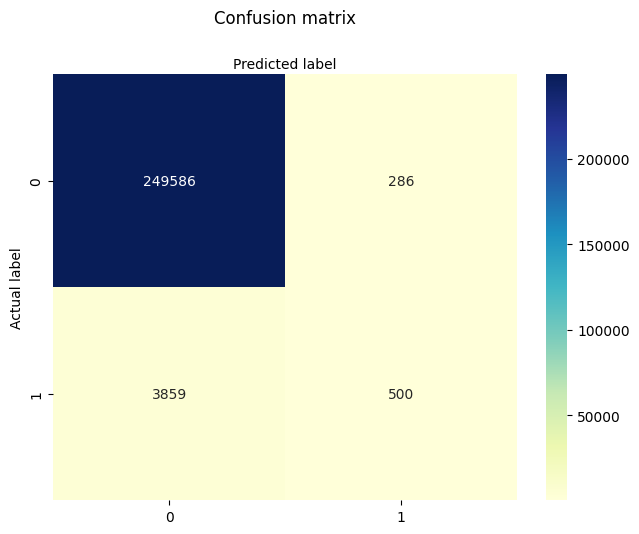

In [23]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [24]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.98      1.00      0.99    249872
     with IP       0.64      0.11      0.19      4359

    accuracy                           0.98    254231
   macro avg       0.81      0.56      0.59    254231
weighted avg       0.98      0.98      0.98    254231



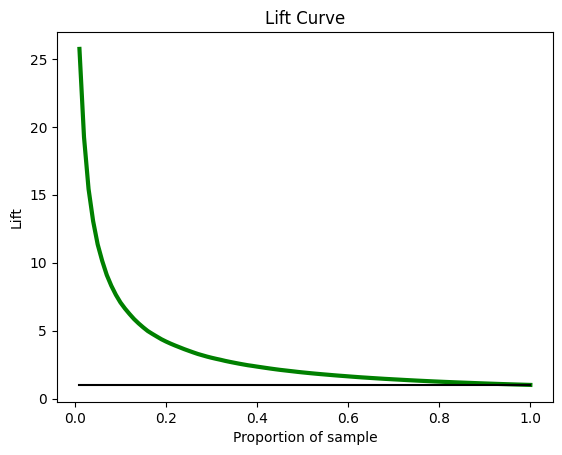

In [25]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(y_test, y_pred_test, step=0.01)


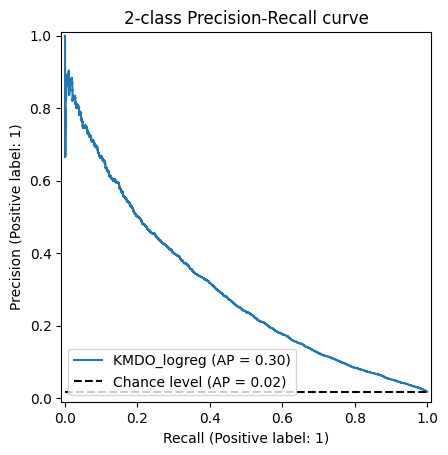

In [26]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [27]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.2996807983791176


In [28]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, y_test, model)
lift_chart.to_csv('lift_chart_xgboost.csv')
lift_chart

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.971965,0.310928,1122,2543,1.000271,25.739849,25.739849,1.000271,25.732865
1,0.310896,0.208355,556,2542,0.999878,12.755219,38.495068,2.000149,19.246095
2,0.208315,0.158850,339,2542,0.999878,7.777013,46.272081,3.000028,15.423885
3,0.158842,0.130918,261,2543,1.000271,5.987612,52.259693,4.000299,13.063947
4,0.130914,0.109802,195,2542,0.999878,4.473503,56.733196,5.000177,11.346237
...,...,...,...,...,...,...,...,...,...
95,0.002183,0.002103,1,2542,0.999878,0.022941,99.885295,95.999701,1.040475
96,0.002103,0.001983,1,2543,1.000271,0.022941,99.908236,96.999972,1.029982
97,0.001983,0.001854,2,2542,0.999878,0.045882,99.954118,97.999851,1.019942
98,0.001854,0.001612,1,2542,0.999878,0.022941,99.977059,98.999729,1.009872


In [29]:
feature_importances = model.get_booster().get_score(importance_type='weight') 
importance_df = pd.DataFrame(feature_importances.items(), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance
print(importance_df)
importance_df.to_csv('importance_df_xgboost.csv')

              Feature  Importance
44             agenbr     33302.0
56              emb58     25677.0
65             emb212     23783.0
62             emb154     23676.0
70             emb238     23475.0
..                ...         ...
32                SCA      1644.0
2   acute_ip_flag_yr1      1627.0
30          paralysis      1498.0
27                MOH      1473.0
25               esrd       868.0

[78 rows x 2 columns]


In [30]:
y_pred = model.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)

threshold = 0.3

y_predict_prob =model.predict_proba(X_test)[:, 1]
y_predict_lab = ((model.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,248320,1552
1,3195,1164


In [33]:
df_out = pd.merge(y_pred, merged, how = 'left',left_index = True, right_index = True)

In [34]:
df_out.head()

,acute_ip_flag_x,y_predict_prob,y_predict_class,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,low_sev_ed_visits_yr1,low_med_sev_ed_visits_yr1,...,ethnicity_code_ETHN0025,ethnicity_code_ETHN0029,primarylanguage_desc_ARABIC,primarylanguage_desc_CHINESE,primarylanguage_desc_ENGLISH,primarylanguage_desc_No Language,primarylanguage_desc_SPANISH,primarylanguage_desc_UNKNOWN,primarylanguage_desc_VIETNAMESE,acute_ip_flag_y
asdb_member_key,,,,,,,,,,,,,,,,,,,,,
460905432,0,0.003313,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
281293134,0,0.003868,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
72483264,0,0.008883,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
560044754,0,0.004052,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
460959528,0,0.018611,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [35]:
df_out.shape

(254231, 662)

In [36]:
m0_3 = df_out.loc[merged['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = df_out.loc[merged['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[merged['tenure_yr1'].isin([9,10,11,12,13,])]

In [37]:
Foster = df_out[df_out['coa_population_category_Foster'] == 1]

Medicare = df_out[df_out['coa_population_category_DSNP Medicare Only'] == 1]

ABD = df_out[(df_out['coa_population_category_DD'] == 1) | 
             (df_out['coa_population_category_ABD Non Dual Non LTSS'] == 1)]

LTSS = df_out[(df_out['coa_population_category_ABD Non Dual LTSS'] == 1) | 
              (df_out['coa_population_category_Dual Elig LTSS'] == 1) |
              (df_out['coa_population_category_Dual Int LTSS'] == 1) |
              (df_out['coa_population_category_LTSS Only'] == 1) ]

Dual = df_out[(df_out['coa_population_category_Dual Elig NonLTSS'] == 1) | 
             (df_out['coa_population_category_Dual Int NonLTSS'] == 1)]

BH = df_out[(df_out['coa_population_category_BH Int SMI'] == 1) | 
             (df_out['coa_population_category_BH Only'] == 1)]

Adult = df_out[(df_out['coa_population_category_Expansion'] == 1) | 
             ((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] >= 18)) |
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] >= 18))]

Kid = df_out[((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] < 18)) | 
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] < 18)) ]

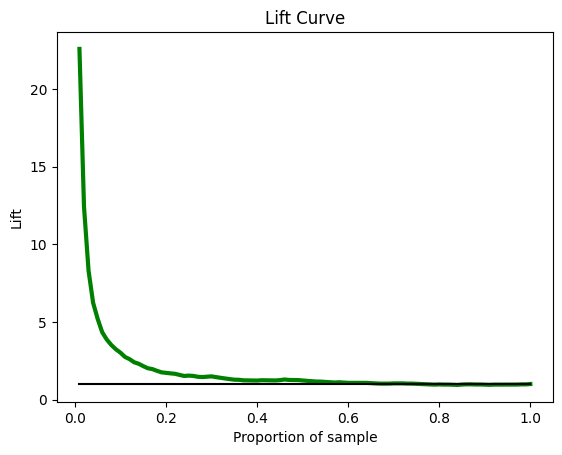

In [38]:
plot_lift_curve(Foster['acute_ip_flag_x'], Foster['y_predict_class'], step=0.01)

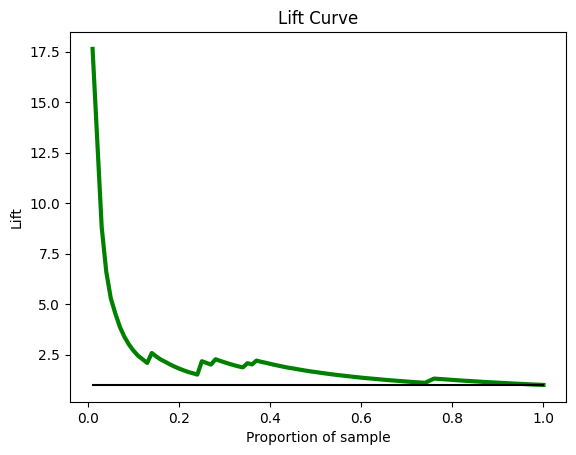

In [39]:
plot_lift_curve(Medicare['acute_ip_flag_x'], Medicare['y_predict_class'], step=0.01)

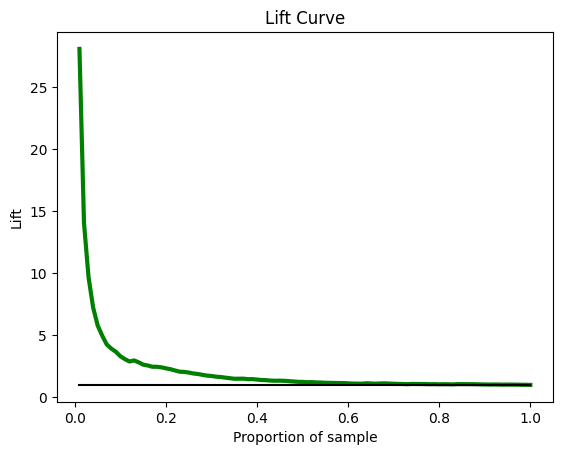

In [40]:
plot_lift_curve(LTSS['acute_ip_flag_x'], LTSS['y_predict_class'], step=0.01)

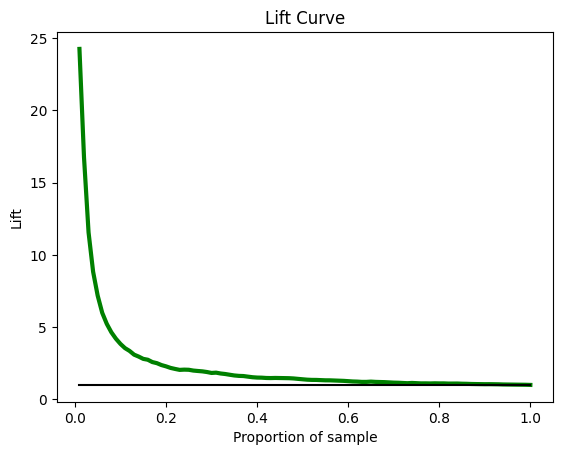

In [41]:
plot_lift_curve(Dual['acute_ip_flag_x'], Dual['y_predict_class'], step=0.01)

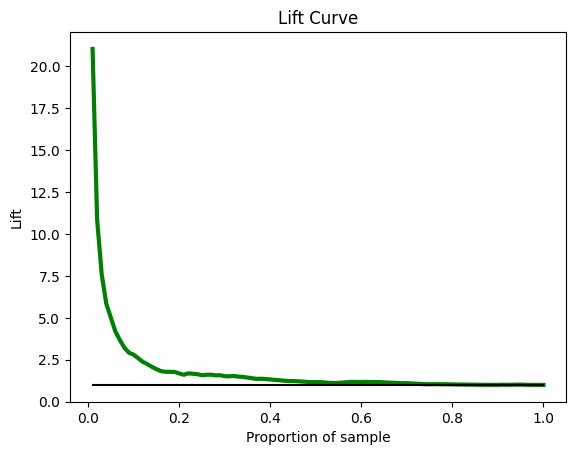

In [42]:
plot_lift_curve(BH['acute_ip_flag_x'], BH['y_predict_class'], step=0.01)

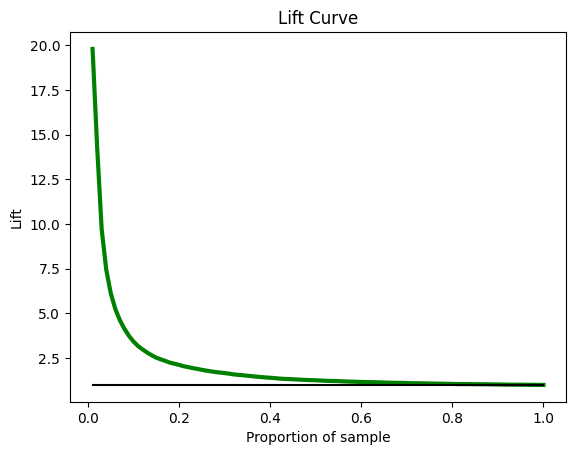

In [43]:
plot_lift_curve(Adult['acute_ip_flag_x'], Adult['y_predict_class'], step=0.01)

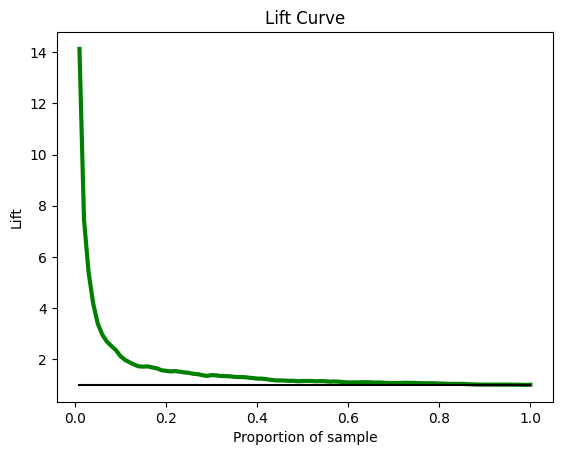

In [44]:
plot_lift_curve(Kid['acute_ip_flag_x'], Kid['y_predict_class'], step=0.01)

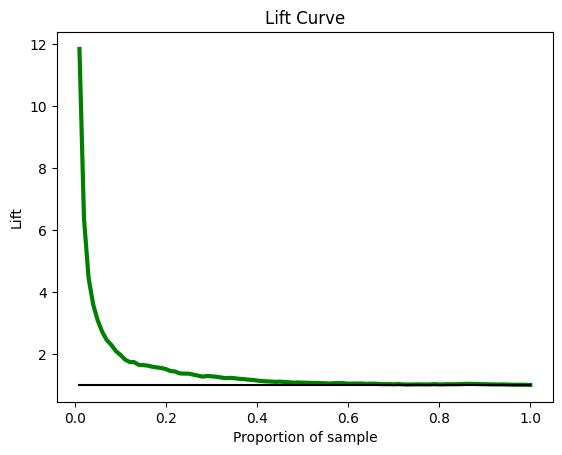

In [45]:
plot_lift_curve(m0_3['acute_ip_flag_x'], m0_3['y_predict_class'], step=0.01)

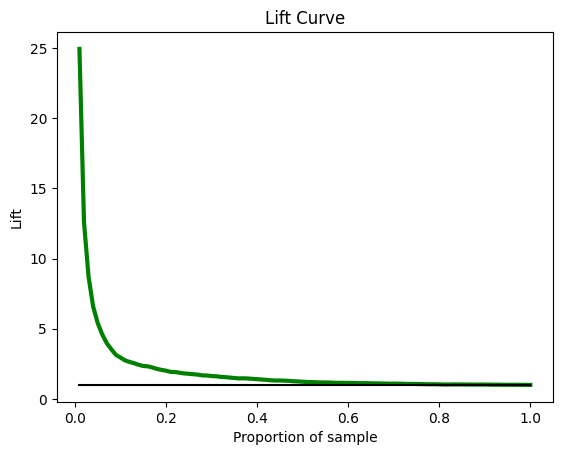

In [46]:
plot_lift_curve(m4_8['acute_ip_flag_x'], m4_8['y_predict_class'], step=0.01)

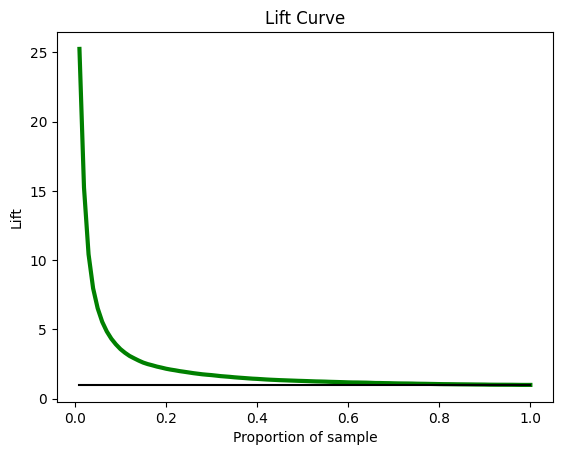

In [47]:
plot_lift_curve(m_9_13['acute_ip_flag_x'], m_9_13['y_predict_class'], step=0.01)

In [48]:
print("% admitted post 6 months ABD: ", ABD['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Medicare: ", Medicare['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Foster: ", Foster['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Medicaid Adult: ", Adult['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Medicaid Kid: ", Kid['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months Dual: ", Dual['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months BH: ", BH['acute_ip_flag_x'].mean()*100)
print("% admitted post 6 months LTSS: ", LTSS['acute_ip_flag_x'].mean()*100)


% admitted post 6 months ABD:  1.833021139951833
% admitted post 6 months Medicare:  1.8900343642611683
% admitted post 6 months Foster:  1.5228426395939088
% admitted post 6 months Medicaid Adult:  2.1957375210319685
% admitted post 6 months Medicaid Kid:  0.6214009174610404
% admitted post 6 months Dual:  1.5859201237791318
% admitted post 6 months BH:  1.741640127388535
% admitted post 6 months LTSS:  1.6175319593008088


In [49]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [50]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.889485,0.070540,322,2704,10.001480,54.668930,54.668930,10.001480,5.466084
1,0.070540,0.042554,101,2704,10.001480,17.147708,71.816638,20.002959,3.590301
2,0.042554,0.027653,62,2703,9.997781,10.526316,82.342954,30.000740,2.744697
3,0.027652,0.018276,34,2704,10.001480,5.772496,88.115450,40.002219,2.202764
4,0.018273,0.012232,23,2703,9.997781,3.904924,92.020374,50.000000,1.840407
5,0.012231,0.008611,18,2704,10.001480,3.056027,95.076401,60.001480,1.584568
6,0.008611,0.006671,12,2703,9.997781,2.037351,97.113752,69.999260,1.387354
7,0.006671,0.005315,8,2704,10.001480,1.358234,98.471986,80.000740,1.230888
8,0.005315,0.003891,7,2703,9.997781,1.188455,99.660441,89.998520,1.107356
9,0.003891,0.000699,2,2704,10.001480,0.339559,100.000000,100.000000,1.000000


In [51]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.851642,0.053777,301,2359,10.003817,72.182254,72.182254,10.003817,7.215472
1,0.053775,0.026511,48,2358,9.999576,11.510791,83.693046,20.003393,4.183943
2,0.026505,0.017634,21,2358,9.999576,5.035971,88.729017,30.002968,2.957341
3,0.017632,0.012674,14,2358,9.999576,3.357314,92.086331,40.002544,2.302012
4,0.012672,0.009065,15,2358,9.999576,3.597122,95.683453,50.002120,1.913588
5,0.009064,0.006587,5,2358,9.999576,1.199041,96.882494,60.001696,1.614663
6,0.006586,0.005023,8,2358,9.999576,1.918465,98.800959,70.001272,1.411417
7,0.005022,0.003856,1,2358,9.999576,0.239808,99.040767,80.000848,1.237996
8,0.003856,0.003087,0,2358,9.999576,0.000000,99.040767,90.000424,1.100448
9,0.003087,0.000570,4,2358,9.999576,0.959233,100.000000,100.000000,1.000000


In [52]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.971965,0.056787,2453,20362,10.000295,73.158366,73.158366,10.000295,7.315621
1,0.056786,0.024943,417,20361,9.999804,12.436624,85.594990,20.000098,4.279728
2,0.024941,0.014435,192,20361,9.999804,5.726215,91.321205,29.999902,3.044050
3,0.014435,0.009545,106,20362,10.000295,3.161348,94.482553,40.000196,2.362052
4,0.009544,0.006748,70,20361,9.999804,2.087683,96.570236,50.000000,1.931405
5,0.006747,0.005086,41,20361,9.999804,1.222786,97.793021,59.999804,1.629889
6,0.005086,0.003947,33,20362,10.000295,0.984193,98.777214,70.000098,1.411101
7,0.003947,0.003128,21,20361,9.999804,0.626305,99.403519,79.999902,1.242546
8,0.003128,0.002494,10,20361,9.999804,0.298240,99.701760,89.999705,1.107801
9,0.002494,0.000517,10,20362,10.000295,0.298240,100.000000,100.000000,1.000000


In [53]:
lift_chart(Foster)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.877555,0.059953,69,631,10.009518,71.875000,71.875000,10.009518,7.180666
1,0.059893,0.027076,10,630,9.993655,10.416667,82.291667,20.003173,4.113931
2,0.027071,0.015817,6,630,9.993655,6.250000,88.541667,29.996827,2.951701
3,0.015814,0.010283,3,631,10.009518,3.125000,91.666667,40.006345,2.291303
4,0.010276,0.007178,2,630,9.993655,2.083333,93.750000,50.000000,1.875000
5,0.007177,0.005418,3,630,9.993655,3.125000,96.875000,59.993655,1.614754
6,0.005416,0.004192,0,631,10.009518,0.000000,96.875000,70.003173,1.383866
7,0.004192,0.003324,0,630,9.993655,0.000000,96.875000,79.996827,1.210986
8,0.003322,0.002595,3,630,9.993655,3.125000,100.000000,89.990482,1.111229
9,0.002594,0.000979,0,631,10.009518,0.000000,100.000000,100.000000,1.000000


In [54]:
lift_chart(Medicare)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.662691,0.064690,10,59,10.137457,90.909091,90.909091,10.137457,8.967643
1,0.062855,0.025384,1,58,9.965636,9.090909,100.000000,20.103093,4.974359
2,0.024922,0.014248,0,58,9.965636,0.000000,100.000000,30.068729,3.325714
3,0.014123,0.008758,0,58,9.965636,0.000000,100.000000,40.034364,2.497854
4,0.008751,0.006796,0,58,9.965636,0.000000,100.000000,50.000000,2.000000
5,0.006784,0.005299,0,58,9.965636,0.000000,100.000000,59.965636,1.667622
6,0.005241,0.004036,0,58,9.965636,0.000000,100.000000,69.931271,1.429975
7,0.004008,0.003288,0,58,9.965636,0.000000,100.000000,79.896907,1.251613
8,0.003268,0.002458,0,58,9.965636,0.000000,100.000000,89.862543,1.112811
9,0.002426,0.000942,0,59,10.137457,0.000000,100.000000,100.000000,1.000000


In [55]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.931558,0.061934,195,1495,10.001338,71.167883,71.167883,10.001338,7.115836
1,0.061834,0.027886,35,1495,10.001338,12.773723,83.941606,20.002676,4.196519
2,0.027878,0.016345,19,1495,10.001338,6.934307,90.875912,30.004014,3.028792
3,0.016343,0.010425,10,1494,9.994648,3.649635,94.525547,39.998662,2.363218
4,0.010425,0.007328,7,1495,10.001338,2.554745,97.080292,50.000000,1.941606
5,0.007328,0.005494,2,1495,10.001338,0.729927,97.810219,60.001338,1.630134
6,0.005494,0.004192,2,1494,9.994648,0.729927,98.540146,69.995986,1.407797
7,0.004191,0.003308,0,1495,10.001338,0.000000,98.540146,79.997324,1.231793
8,0.003308,0.002608,3,1495,10.001338,1.094891,99.635036,89.998662,1.107072
9,0.002607,0.000758,1,1495,10.001338,0.364964,100.000000,100.000000,1.000000


In [56]:
lift_chart(LTSS)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.861144,0.067022,89,767,10.005218,71.774194,71.774194,10.005218,7.173676
1,0.066831,0.028872,13,767,10.005218,10.483871,82.258065,20.010436,4.110758
2,0.028865,0.016698,6,766,9.992173,4.838710,87.096774,30.002609,2.902973
3,0.016677,0.010915,6,767,10.005218,4.838710,91.935484,40.007827,2.297937
4,0.010914,0.007642,5,766,9.992173,4.032258,95.967742,50.000000,1.919355
5,0.007635,0.005705,3,767,10.005218,2.419355,98.387097,60.005218,1.639642
6,0.005697,0.004352,1,766,9.992173,0.806452,99.193548,69.997391,1.417104
7,0.004346,0.003387,1,767,10.005218,0.806452,100.000000,80.002609,1.249959
8,0.003387,0.002617,0,766,9.992173,0.000000,100.000000,89.994782,1.111176
9,0.002617,0.000570,0,767,10.005218,0.000000,100.000000,100.000000,1.000000


In [57]:
lift_chart(Dual)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.933854,0.059335,120,1035,10.008703,73.170732,73.170732,10.008703,7.310710
1,0.059306,0.027769,22,1034,9.999033,13.414634,86.585366,20.007736,4.327594
2,0.027763,0.016183,8,1034,9.999033,4.878049,91.463415,30.006769,3.048093
3,0.016180,0.010744,6,1034,9.999033,3.658537,95.121951,40.005802,2.377704
4,0.010741,0.007577,2,1034,9.999033,1.219512,96.341463,50.004835,1.926643
5,0.007577,0.005655,1,1034,9.999033,0.609756,96.951220,60.003868,1.615749
6,0.005654,0.004298,0,1033,9.989363,0.000000,96.951220,69.993231,1.385151
7,0.004298,0.003323,3,1035,10.008703,1.829268,98.780488,80.001934,1.234726
8,0.003323,0.002583,2,1034,9.999033,1.219512,100.000000,90.000967,1.111099
9,0.002583,0.000866,0,1034,9.999033,0.000000,100.000000,100.000000,1.000000


In [58]:
lift_chart(BH)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.823444,0.057843,107,1005,10.001990,61.142857,61.142857,10.001990,6.113069
1,0.057786,0.026954,27,1005,10.001990,15.428571,76.571429,20.003981,3.827810
2,0.026952,0.016024,23,1005,10.001990,13.142857,89.714286,30.005971,2.989881
3,0.016013,0.010451,8,1004,9.992038,4.571429,94.285714,39.998010,2.357260
4,0.010448,0.007349,6,1005,10.001990,3.428571,97.714286,50.000000,1.954286
5,0.007349,0.005583,2,1005,10.001990,1.142857,98.857143,60.001990,1.647564
6,0.005581,0.004298,2,1004,9.992038,1.142857,100.000000,69.994029,1.428693
7,0.004298,0.003357,0,1005,10.001990,0.000000,100.000000,79.996019,1.250062
8,0.003357,0.002596,0,1005,10.001990,0.000000,100.000000,89.998010,1.111136
9,0.002596,0.000660,0,1005,10.001990,0.000000,100.000000,100.000000,1.000000


In [59]:
lift_chart(Adult)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.971965,0.077807,2150,14264,10.0,68.646232,68.646232,10.0,6.864623
1,0.077795,0.037368,421,14264,10.0,13.441890,82.088123,20.0,4.104406
2,0.037367,0.022467,229,14264,10.0,7.311622,89.399745,30.0,2.979991
3,0.022465,0.014948,115,14264,10.0,3.671775,93.071520,40.0,2.326788
4,0.014948,0.010515,78,14264,10.0,2.490421,95.561941,50.0,1.911239
5,0.010515,0.007630,48,14264,10.0,1.532567,97.094508,60.0,1.618242
6,0.007630,0.005735,50,14264,10.0,1.596424,98.690932,70.0,1.409870
7,0.005735,0.004288,20,14264,10.0,0.638570,99.329502,80.0,1.241619
8,0.004288,0.003106,13,14264,10.0,0.415070,99.744572,90.0,1.108273
9,0.003106,0.000701,8,14264,10.0,0.255428,100.000000,100.0,1.000000


In [60]:
lift_chart(Kid)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.871469,0.017079,265,6148,10.000976,69.371728,69.371728,10.000976,6.936496
1,0.017075,0.008832,48,6147,9.999349,12.565445,81.937173,20.000325,4.096792
2,0.008832,0.006144,26,6147,9.999349,6.806283,88.743455,29.999675,2.958147
3,0.006144,0.004768,12,6148,10.000976,3.141361,91.884817,40.000651,2.297083
4,0.004767,0.003945,12,6147,9.999349,3.141361,95.026178,50.000000,1.900524
5,0.003945,0.003362,5,6147,9.999349,1.308901,96.335079,59.999349,1.605602
6,0.003362,0.002919,5,6148,10.000976,1.308901,97.643979,70.000325,1.394908
7,0.002919,0.002534,2,6147,9.999349,0.523560,98.167539,79.999675,1.227099
8,0.002533,0.002146,4,6147,9.999349,1.047120,99.214660,89.999024,1.102397
9,0.002146,0.000517,3,6148,10.000976,0.785340,100.000000,100.000000,1.000000


In [61]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df  

In [62]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.889485,0.200392,112,271,1.002367,19.015280,19.015280,1.002367,18.970373
1,0.200179,0.158873,42,270,0.998668,7.130730,26.146010,2.001036,13.066239
2,0.158842,0.138383,32,271,1.002367,5.432937,31.578947,3.003403,10.514389
3,0.137895,0.123209,19,270,0.998668,3.225806,34.804754,4.002071,8.696685
4,0.123197,0.109244,26,270,0.998668,4.414261,39.219015,5.000740,7.842643
...,...,...,...,...,...,...,...,...,...
95,0.002977,0.002627,0,270,0.998668,0.000000,100.000000,95.997929,1.041689
96,0.002625,0.002268,0,270,0.998668,0.000000,100.000000,96.996597,1.030964
97,0.002266,0.001868,0,271,1.002367,0.000000,100.000000,97.998964,1.020419
98,0.001867,0.001425,0,270,0.998668,0.000000,100.000000,98.997633,1.010125


In [63]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.851642,0.302869,104,236,1.000806,24.940048,24.940048,1.000806,24.919969
1,0.301823,0.208484,63,236,1.000806,15.107914,40.047962,2.001611,20.007860
2,0.208404,0.154748,29,236,1.000806,6.954436,47.002398,3.002417,15.654852
3,0.154663,0.124379,21,236,1.000806,5.035971,52.038369,4.003223,12.999119
4,0.124208,0.102388,22,236,1.000806,5.275779,57.314149,5.004029,11.453601
...,...,...,...,...,...,...,...,...,...
95,0.002633,0.002448,1,235,0.996565,0.239808,99.760192,95.996777,1.039204
96,0.002448,0.002175,0,236,1.000806,0.000000,99.760192,96.997583,1.028481
97,0.002175,0.001894,0,236,1.000806,0.000000,99.760192,97.998389,1.017978
98,0.001894,0.001573,0,236,1.000806,0.000000,99.760192,98.999194,1.007687


In [64]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.971965,0.325116,911,2037,1.000422,27.169699,27.169699,1.000422,27.158228
1,0.325062,0.217126,436,2036,0.999931,13.003281,40.172979,2.000354,20.082939
2,0.217112,0.164433,293,2036,0.999931,8.738443,48.911423,3.000285,16.302260
3,0.164398,0.133374,214,2036,0.999931,6.382344,55.293767,4.000216,13.822695
4,0.133373,0.110982,151,2036,0.999931,4.503430,59.797197,5.000147,11.959087
...,...,...,...,...,...,...,...,...,...
95,0.002145,0.002068,0,2036,0.999931,0.000000,99.880704,95.999784,1.040426
96,0.002068,0.001968,2,2036,0.999931,0.059648,99.940352,96.999715,1.030316
97,0.001968,0.001854,1,2036,0.999931,0.029824,99.970176,97.999646,1.020108
98,0.001854,0.001632,1,2036,0.999931,0.029824,100.000000,98.999578,1.010105


In [65]:
lift_chart(Foster) 

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.877555,0.321069,24,64,1.015228,25.000000,25.000000,1.015228,24.625000
1,0.318996,0.234569,14,63,0.999365,14.583333,39.583333,2.014594,19.648294
2,0.232214,0.173588,8,63,0.999365,8.333333,47.916667,3.013959,15.898246
3,0.173475,0.143609,5,63,0.999365,5.208333,53.125000,4.013325,13.237154
4,0.143326,0.121251,7,63,0.999365,7.291667,60.416667,5.012690,12.052743
...,...,...,...,...,...,...,...,...,...
95,0.002233,0.002137,0,63,0.999365,0.000000,100.000000,95.986675,1.041811
96,0.002134,0.002013,0,63,0.999365,0.000000,100.000000,96.986041,1.031076
97,0.002010,0.001876,0,63,0.999365,0.000000,100.000000,97.985406,1.020560
98,0.001875,0.001676,0,63,0.999365,0.000000,100.000000,98.984772,1.010256


In [66]:
lift_chart(Medicare)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.662691,0.357719,3,6,1.030928,27.272727,27.272727,1.030928,26.454545
1,0.337172,0.275075,1,6,1.030928,9.090909,36.363636,2.061856,17.636364
2,0.265926,0.172359,0,6,1.030928,0.000000,36.363636,3.092784,11.757576
3,0.168074,0.154915,0,6,1.030928,0.000000,36.363636,4.123711,8.818182
4,0.151359,0.142416,0,6,1.030928,0.000000,36.363636,5.154639,7.054545
...,...,...,...,...,...,...,...,...,...
95,0.002108,0.002062,0,6,1.030928,0.000000,100.000000,95.876289,1.043011
96,0.002056,0.001967,0,6,1.030928,0.000000,100.000000,96.907216,1.031915
97,0.001967,0.001809,0,6,1.030928,0.000000,100.000000,97.938144,1.021053
98,0.001807,0.001712,0,6,1.030928,0.000000,100.000000,98.969072,1.010417


In [67]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.931558,0.331989,63,150,1.003479,22.992701,22.992701,1.003479,22.912993
1,0.331868,0.214050,43,149,0.996789,15.693431,38.686131,2.000268,19.340478
2,0.213697,0.164336,22,150,1.003479,8.029197,46.715328,3.003746,15.552355
3,0.164180,0.137167,17,149,0.996789,6.204380,52.919708,4.000535,13.228157
4,0.137150,0.116020,12,150,1.003479,4.379562,57.299270,5.004014,11.450662
...,...,...,...,...,...,...,...,...,...
95,0.002202,0.002103,0,150,1.003479,0.000000,100.000000,95.999465,1.041672
96,0.002102,0.001972,0,149,0.996789,0.000000,100.000000,96.996254,1.030968
97,0.001971,0.001845,0,150,1.003479,0.000000,100.000000,97.999732,1.020411
98,0.001845,0.001590,0,149,0.996789,0.000000,100.000000,98.996521,1.010137


In [68]:
lift_chart(LTSS)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.861144,0.306185,35,77,1.004435,28.225806,28.225806,1.004435,28.101173
1,0.299945,0.221237,16,77,1.004435,12.903226,41.129032,2.008870,20.473712
2,0.220461,0.174134,1,76,0.991391,0.806452,41.935484,3.000261,13.977279
3,0.174115,0.143611,10,77,1.004435,8.064516,50.000000,4.004696,12.485342
4,0.143353,0.125443,8,77,1.004435,6.451613,56.451613,5.009131,11.269741
...,...,...,...,...,...,...,...,...,...
95,0.002178,0.002088,0,77,1.004435,0.000000,100.000000,95.995304,1.041718
96,0.002086,0.001964,0,77,1.004435,0.000000,100.000000,96.999739,1.030931
97,0.001963,0.001810,0,76,0.991391,0.000000,100.000000,97.991130,1.020501
98,0.001810,0.001577,0,77,1.004435,0.000000,100.000000,98.995565,1.010146


In [69]:
lift_chart(Dual)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.933854,0.341174,44,104,1.005705,26.829268,26.829268,1.005705,26.677064
1,0.339340,0.228097,25,103,0.996035,15.243902,42.073171,2.001741,21.018293
2,0.225634,0.164261,12,104,1.005705,7.317073,49.390244,3.007446,16.422653
3,0.163363,0.134523,11,103,0.996035,6.707317,56.097561,4.003481,14.012195
4,0.134135,0.110349,10,104,1.005705,6.097561,62.195122,5.009187,12.416212
...,...,...,...,...,...,...,...,...,...
95,0.002205,0.002118,0,103,0.996035,0.000000,100.000000,95.996519,1.041704
96,0.002115,0.002021,0,103,0.996035,0.000000,100.000000,96.992554,1.031007
97,0.002020,0.001891,0,104,1.005705,0.000000,100.000000,97.998259,1.020426
98,0.001891,0.001628,0,103,0.996035,0.000000,100.000000,98.994295,1.010159


In [70]:
lift_chart(BH)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.823444,0.295467,38,101,1.005175,21.714286,21.714286,1.005175,21.602489
1,0.293089,0.199702,21,100,0.995223,12.000000,33.714286,2.000398,16.853788
2,0.198863,0.153343,15,101,1.005175,8.571429,42.285714,3.005573,14.069101
3,0.153040,0.125129,11,100,0.995223,6.285714,48.571429,4.000796,12.140441
4,0.124948,0.107523,4,101,1.005175,2.285714,50.857143,5.005971,10.159296
...,...,...,...,...,...,...,...,...,...
95,0.002217,0.002114,0,101,1.005175,0.000000,100.000000,95.999204,1.041675
96,0.002112,0.002017,0,100,0.995223,0.000000,100.000000,96.994427,1.030987
97,0.002017,0.001862,0,101,1.005175,0.000000,100.000000,97.999602,1.020412
98,0.001854,0.001609,0,100,0.995223,0.000000,100.000000,98.994825,1.010154


In [71]:
lift_chart(Adult)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.971965,0.358689,706,1427,1.000421,22.541507,22.541507,1.000421,22.532029
1,0.358665,0.249404,369,1426,0.999720,11.781609,34.323116,2.000140,17.160355
2,0.249188,0.193638,271,1427,1.000421,8.652618,42.975734,3.000561,14.322567
3,0.193632,0.160045,191,1426,0.999720,6.098340,49.074074,4.000280,12.267658
4,0.160040,0.137805,149,1426,0.999720,4.757344,53.831418,5.000000,10.766284
...,...,...,...,...,...,...,...,...,...
95,0.002553,0.002423,0,1426,0.999720,0.000000,99.904215,95.999720,1.040672
96,0.002423,0.002264,1,1426,0.999720,0.031928,99.936143,96.999439,1.030275
97,0.002264,0.002106,0,1427,1.000421,0.000000,99.936143,97.999860,1.019758
98,0.002106,0.001865,1,1426,0.999720,0.031928,99.968072,98.999579,1.009783


In [72]:
lift_chart(Kid)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.871469,0.081222,123,615,1.000423,32.198953,32.198953,1.000423,32.185340
1,0.081208,0.055250,38,615,1.000423,9.947644,42.146597,2.000846,21.064389
2,0.055250,0.046828,27,615,1.000423,7.068063,49.214660,3.001269,16.397951
3,0.046739,0.036582,14,614,0.998796,3.664921,52.879581,4.000065,13.219680
4,0.036569,0.030735,19,615,1.000423,4.973822,57.853403,5.000488,11.569551
...,...,...,...,...,...,...,...,...,...
95,0.001891,0.001835,0,615,1.000423,0.000000,99.738220,95.999935,1.038940
96,0.001835,0.001724,0,614,0.998796,0.000000,99.738220,96.998731,1.028243
97,0.001724,0.001579,0,615,1.000423,0.000000,99.738220,97.999154,1.017746
98,0.001579,0.001384,0,615,1.000423,0.000000,99.738220,98.999577,1.007461
